## Food Product Emissions (Poore & Nemecek) 

Per-kg greenhouse-gas emissions for 43 foods, broken into supply-chain stages.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display


In [39]:
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#edeff2", "axes.edgecolor": "#d4d8de",
    "font.size": 11,
})
ACCENT, MUTED = "#2f6fb0", "#c5cad2"
DATA_DIR = Path("data")   # folder holding the three files

def quick_look(df, name):
    print(f"== {name} ==  shape = {df.shape}")
    display(df.head())
    print("dtypes:\n", df.dtypes, sep="")
    print("missing per column:", df.isna().sum().to_dict())
    num = df.select_dtypes("number").columns.tolist()
    print("numerical:", num)
    print("categorical:", [c for c in df.columns if c not in num])

In [40]:
food = pd.read_csv(DATA_DIR / "Food_Product_Emissions.csv")
PRODUCT = "Food product"
STAGES  = ["Land Use Change", "Feed", "Farm", "Processing", "Transport", "Packaging", "Retail"]
PERKG   = "Total Global Average GHG Emissions per kg"
quick_look(food, "Food Product Emissions")

== Food Product Emissions ==  shape = (43, 11)


,Food product,Land Use Change,Feed,Farm,Processing,Transport,Packaging,Retail,Total from Land to Retail,Total Global Average GHG Emissions per kg,Unit of GHG Emissions
0,Apples,-0.029,0.000,0.225,0.004,0.096,0.044,0.017,0.357,0.43,kg CO2e per kg food produced
1,Bananas,-0.025,0.000,0.266,0.059,0.292,0.065,0.021,0.678,0.86,kg CO2e per kg food produced
2,Barley,0.009,0.000,0.176,0.128,0.035,0.497,0.264,1.109,1.18,kg CO2e per kg food produced
3,Beef (beef herd),16.278,1.878,39.388,1.269,0.346,0.247,0.164,59.570,99.48,kg CO2e per kg food produced
4,Beef (dairy herd),0.906,2.508,15.689,1.108,0.424,0.268,0.182,21.085,33.30,kg CO2e per kg food produced


dtypes:
Food product                                     str
Land Use Change                              float64
Feed                                         float64
Farm                                         float64
Processing                                   float64
Transport                                    float64
Packaging                                    float64
Retail                                       float64
Total from Land to Retail                    float64
Total Global Average GHG Emissions per kg    float64
Unit of GHG Emissions                            str
dtype: object
missing per column: {'Food product': 0, 'Land Use Change': 0, 'Feed': 0, 'Farm': 0, 'Processing': 0, 'Transport': 0, 'Packaging': 0, 'Retail': 0, 'Total from Land to Retail': 0, 'Total Global Average GHG Emissions per kg': 0, 'Unit of GHG Emissions': 0}
numerical: ['Land Use Change', 'Feed', 'Farm', 'Processing', 'Transport', 'Packaging', 'Retail', 'Total from Land to Retail', 'Total Global A

In [41]:
display(food.select_dtypes("number").agg(["mean","median","std","min","max"]).T.round(2))

,mean,median,std,min,max
Land Use Change,1.26,0.18,3.35,-2.05,16.28
Feed,0.46,0.00,0.92,0.00,2.94
Farm,3.47,0.85,7.08,0.09,39.39
Processing,0.26,0.06,0.37,0.00,1.27
Transport,0.19,0.13,0.16,0.04,0.78
Packaging,0.27,0.10,0.34,0.04,1.63
Retail,0.08,0.04,0.09,0.02,0.33
Total from Land to Retail,6.00,1.61,10.49,0.28,59.57
Total Global Average GHG Emissions per kg,9.47,2.48,18.07,0.39,99.48


### Visualization — which foods have the highest land-to-retail emissions per kg

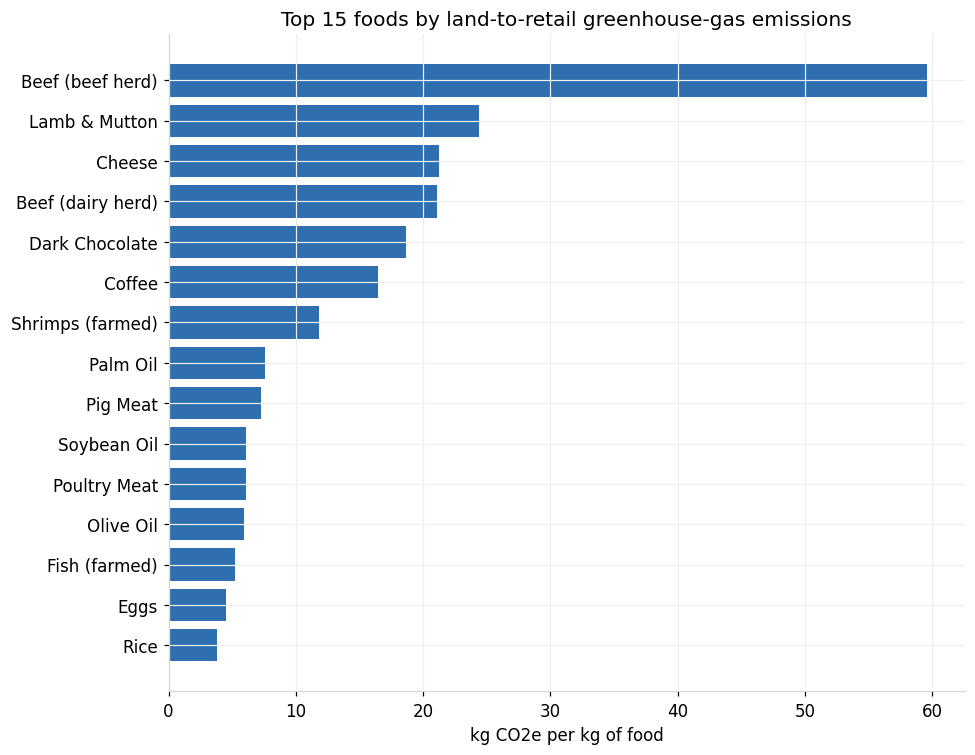

In [42]:
col = "Total from Land to Retail"
top = food.sort_values(col).tail(15)

plt.figure(figsize=(9, 7))
plt.barh(top["Food product"], top[col], color="#2f6fb0")
plt.xlabel("kg CO2e per kg of food")
plt.title("Top 15 foods by land-to-retail greenhouse-gas emissions")
plt.tight_layout()
plt.show()

Takeaway: Land-to-retail emissions vary by roughly 80× across foods. Beef remains the highest-impact product at nearly 60 kg CO2e per kg, followed by dark chocolate and lamb. Animal-based foods dominate the upper end of the distribution, while fruits, grains, and other plant-based foods have substantially lower emissions.

**Box plot** — spread and the high-impact outliers.

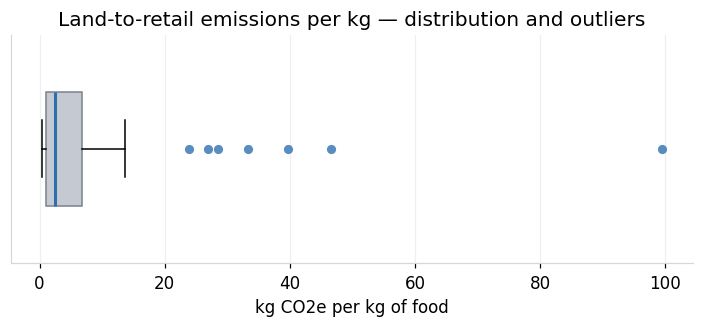

In [43]:

fig, ax = plt.subplots(figsize=(8, 2.7))
ax.boxplot(food[PERKG].dropna(), vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor=MUTED, edgecolor="#7b828d"),
           medianprops=dict(color=ACCENT, linewidth=2),
           flierprops=dict(marker="o", markerfacecolor=ACCENT, markeredgecolor="none", markersize=6, alpha=0.8))
ax.set_title("Land-to-retail emissions per kg — distribution and outliers")
ax.set_xlabel("kg CO2e per kg of food"); ax.set_yticks([])
plt.show()

**Takeaway:** Most foods cluster at relatively low emission levels, while a small number of products form a long right tail of high-emission outliers. This indicates that a few foods account for disproportionately large greenhouse-gas emissions per kilogram.

**Stacked stages** — *where* emissions come from for the highest-impact foods (land-use + farm dominate; transport is tiny).

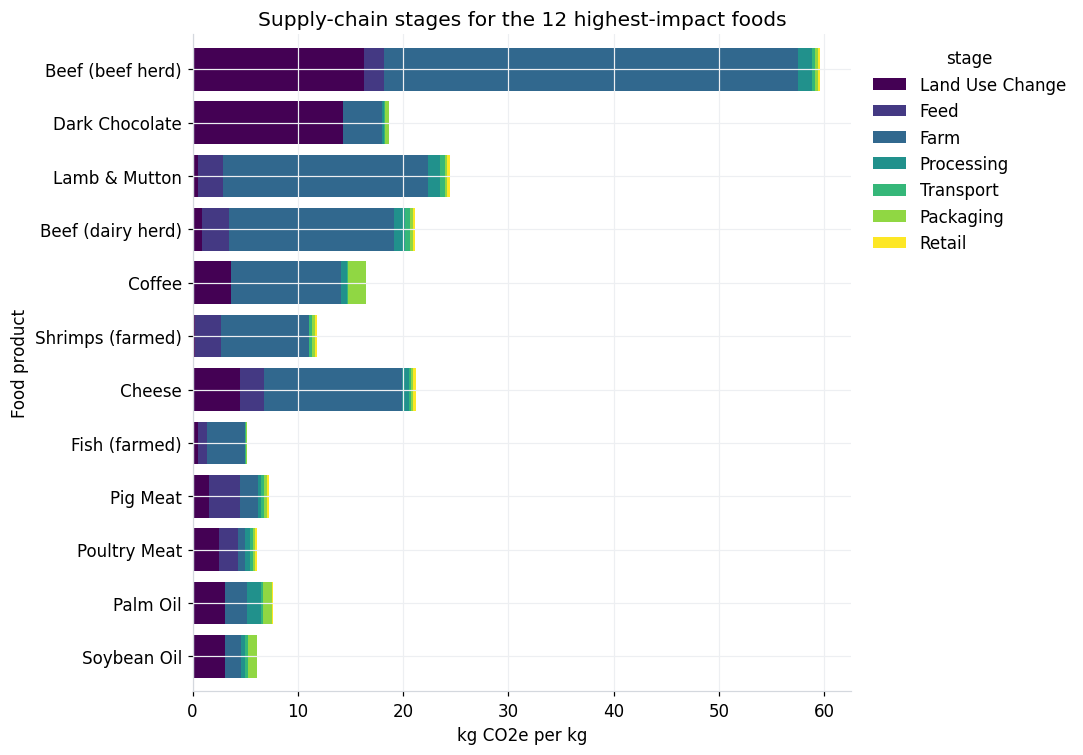

In [44]:
M = 12
sub = food.dropna(subset=[PERKG]).sort_values(PERKG).tail(M).set_index(PRODUCT)[STAGES]
ax = sub.plot(kind="barh", stacked=True, figsize=(10, 7), colormap="viridis", width=0.8)
ax.set_title(f"Supply-chain stages for the {M} highest-impact foods")
ax.set_xlabel("kg CO2e per kg")
ax.legend(title="stage", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout(); plt.show()

Takeaway: Most emissions occur during production rather than distribution. Farm operations and land-use change drive the majority of emissions for high-impact foods, while transport, packaging, and retail contribute relatively little.